In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'src' folder
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'src' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igor\Documents\GitHub\futures_trading_strategies


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import (
    load_simple_price_csv,
    FixedRiskPositionStrategy,
    VectorizedEngine,
    plot_results
)

In [3]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-07-02 15:08:35.421 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-07-02 15:08:35.473 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


In [41]:
INITIAL_CAPITAL = 100000
VOLATILITY_WINDOW = 252
RISK_TARGET = 0.5
MULTIPLIER=1.0
MAX_LEVERAGE=1.0

In [59]:
strategy_fixed = FixedRiskPositionStrategy(volatility_window=VOLATILITY_WINDOW, risk_target=RISK_TARGET, expected_sharpe=10, max_leverage=MAX_LEVERAGE)

In [60]:

engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,     
    commission_rate=0.0004,
    slippage_rate=0.001
)

In [61]:
strategy_fixed_result = engine.run(strategy_fixed, data)

In [62]:
strategy_fixed_result.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: FixedRiskPositionStrategy                │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +7.1% │
│ Average drawdown                         │                    -1.7% │
│ Maximum drawdown                         │                   -37.9% │
│ Annualised standard deviation            │                    11.8% │
│ Sharpe ratio                             │                     0.60 │
│ Skew                                     │                     0.00 │
│ Lower tail                               │                     2.96 │
│ Upper tail                               │                     2.53 │
└──────────────────────────────────────────────────────────────────────┘


CURRENT POSITION DETAILS
current_price                 : 7,470.19
current_volatility            : 0.22
vol_method                    : sma
risk_target                   : 0.50
effective_risk                : 0.50
capital_used                  : 100000
num_contracts                 : 13.00
notional_value                : 97,112.47
risk_contribution             : 0.21


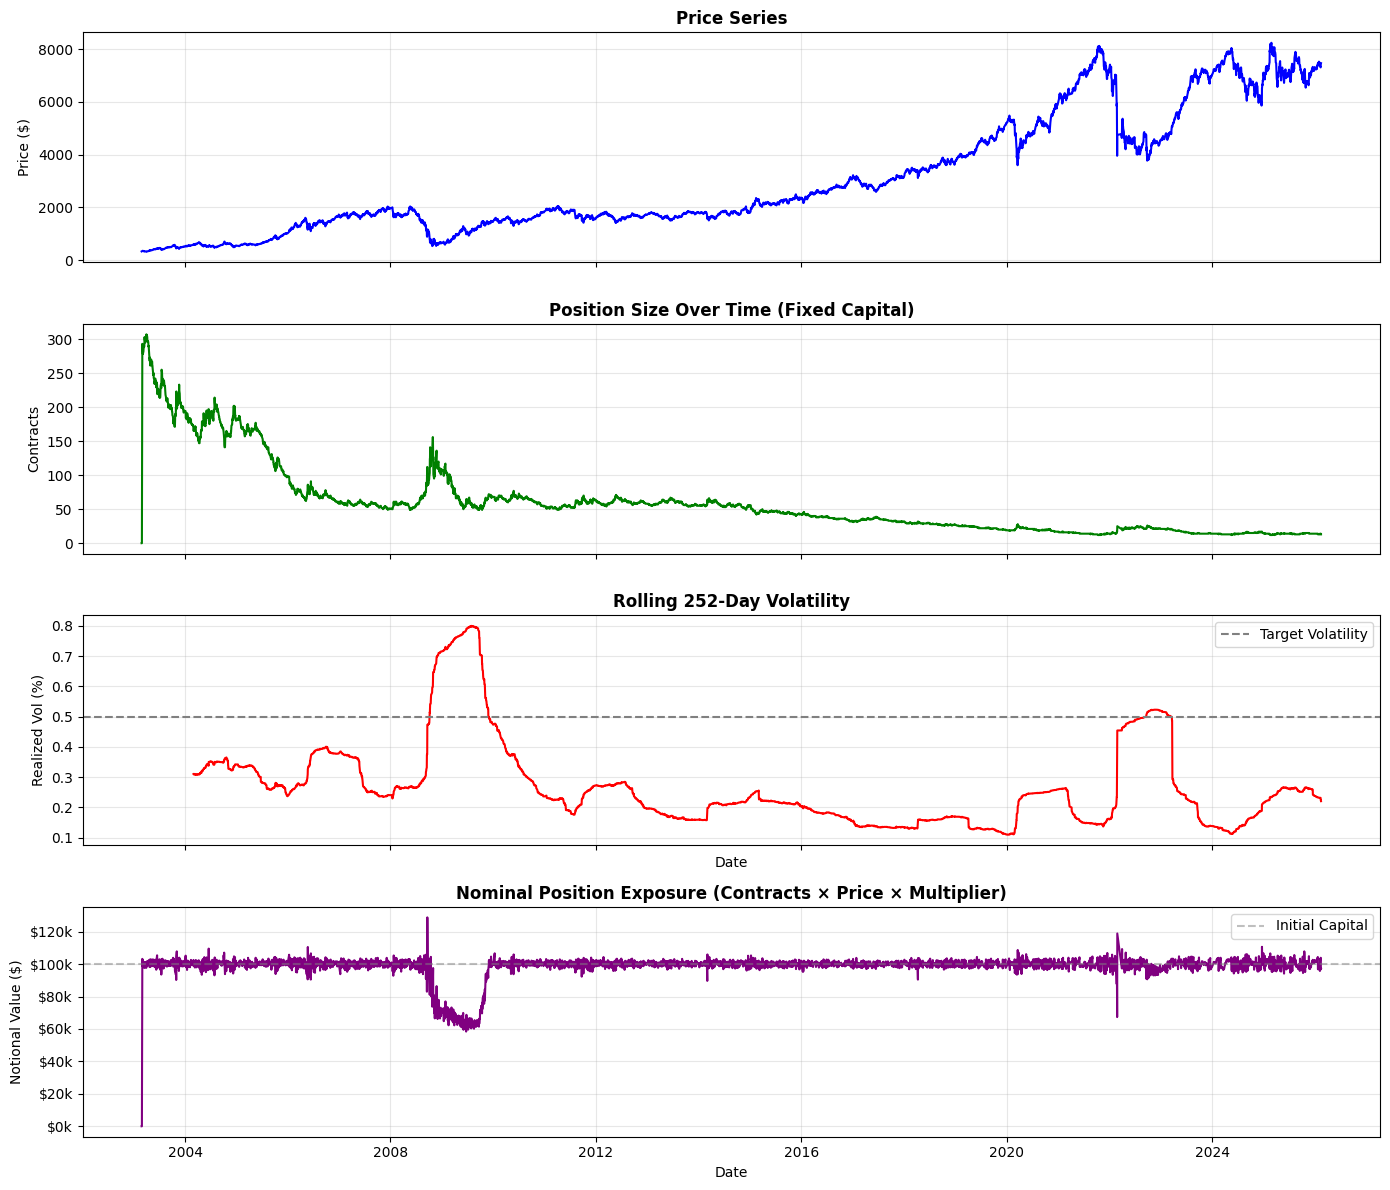

: 

In [ ]:
# Get detailed position info
info = strategy_fixed.get_detailed_info(data, capital=INITIAL_CAPITAL)

print("=" * 80)
print("CURRENT POSITION DETAILS")
print("=" * 80)
for key, value in info.items():
    if isinstance(value, float):
        print(f"{key:30s}: {value:,.2f}")
    else:
        print(f"{key:30s}: {value}")

# %% [markdown]
# ### 7.1 Position Size Time Series

# %%
# Plot position sizes over time
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price
axes[0].plot(data.index, data['close'], linewidth=1.5, color='blue')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price Series', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Panel 2: Positions
axes[1].plot(strategy_fixed_result.positions.index, strategy_fixed_result.positions, 
             linewidth=1.5, color='green')
axes[1].set_ylabel('Contracts')
axes[1].set_title('Position Size Over Time (Fixed Capital)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Panel 3: Volatility
volatility = data['close'].pct_change().rolling(VOLATILITY_WINDOW).std() * np.sqrt(252)
axes[2].plot(volatility.index, volatility, linewidth=1.5, color='red')
axes[2].axhline(RISK_TARGET, color='gray', linestyle='--', label='Target Volatility')
axes[2].set_ylabel('Realized Vol (%)')
axes[2].set_xlabel('Date')
axes[2].set_title(f'Rolling {VOLATILITY_WINDOW}-Day Volatility', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Panel 4: Notional Value (Nominal Exposure)
# Calculate: Notional = Contracts × Price × Multiplier
positions = strategy_fixed_result.positions
notional_value = positions * data['close'] * MULTIPLIER

axes[3].plot(notional_value.index, notional_value, linewidth=1.5, color='purple')
axes[3].axhline(INITIAL_CAPITAL, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
axes[3].set_ylabel('Notional Value ($)')
axes[3].set_xlabel('Date')
axes[3].set_title('Nominal Position Exposure (Contracts × Price × Multiplier)', fontweight='bold')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# Format y-axis for currency
axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y/1000:.0f}k'))

plt.tight_layout()
plt.savefig("../outputs/fixed_risk_strategy/04_position_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

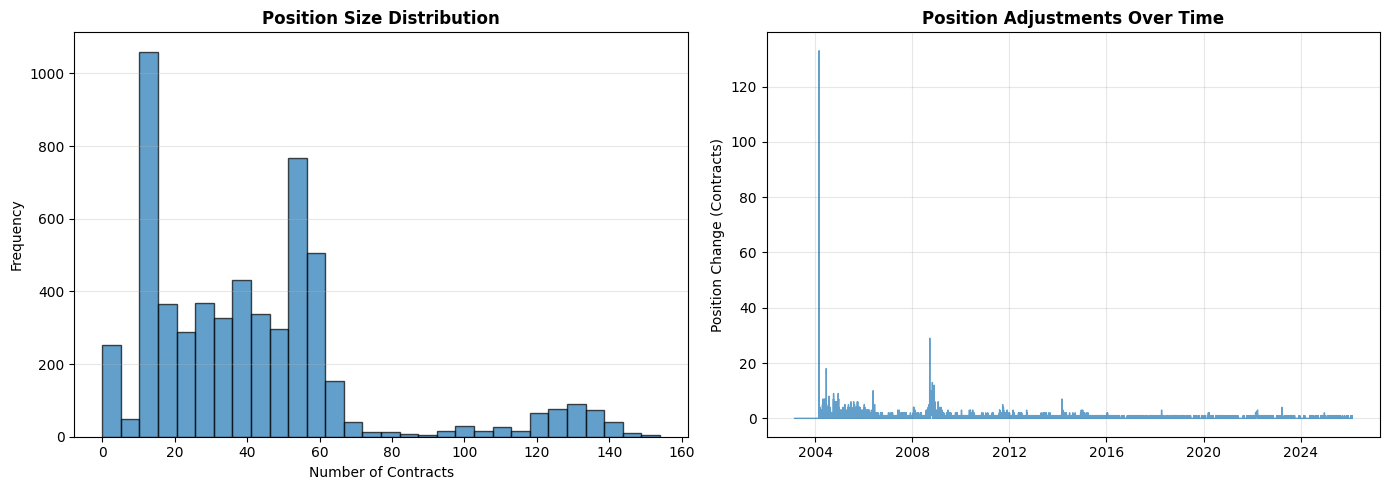

COMPREHENSIVE RISK METRICS
┌──────────────────────────────────────────────────────────────────────
│ Strategy: FixedRiskPositionStrategy                │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +5.8% │
│ Average drawdown                         │                    -2.0% │
│ Maximum drawdown                         │                   -36.3% │
│ Annualised standard deviation            │                    11.8% │
│ Sharpe ratio                             │                     0.49 │
│ Skew                                     │                     0.01 │
│ Lower tail                               │                     3.01 │
│ Upper tail                               │                     2.32 │
└──────────────────────────────────────────────────────────────────────┘

TAIL RISK ANALYSIS
Lower

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(strategy_fixed_result.positions.dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Contracts')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Position Size Distribution', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Time series of position changes
pos_changes = strategy_fixed_result.positions.diff().abs()
axes[1].plot(pos_changes.index, pos_changes, linewidth=1, alpha=0.7)
axes[1].set_ylabel('Position Change (Contracts)')
axes[1].set_title('Position Adjustments Over Time', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/fixed_risk_strategy/05_position_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 8. Risk Metrics Deep Dive <a id="metrics"></a>

# %%
# Comprehensive risk analysis
print("=" * 80)
print("COMPREHENSIVE RISK METRICS")
print("=" * 80)

strategy_fixed_result.print_summary()

# Additional analysis
print("\n" + "=" * 80)
print("TAIL RISK ANALYSIS")
print("=" * 80)
print(f"Lower Tail Ratio: {strategy_fixed_result.metrics['lower_tail']:.3f}")
print(f"Upper Tail Ratio: {strategy_fixed_result.metrics['upper_tail']:.3f}")
print(f"Combined Tail Risk: {strategy_fixed_result.metrics['tail_risk']:.3f}")
print("\nInterpretation:")
print(f"  • Lower tail > 1.0: Extreme losses are {'more' if strategy_fixed_result.metrics['lower_tail'] > 1 else 'less'} severe than normal")
print(f"  • Upper tail > 1.0: Extreme gains are {'more' if strategy_fixed_result.metrics['upper_tail'] > 1 else 'less'} severe than normal")